In [2]:
import sys
import scanpy as sc
import muon as mu
import scvi
import anndata as ad
import mudata

print("Python:", sys.version)
print("scanpy:", sc.__version__)
print("muon:", mu.__version__)
print("scvi-tools:", scvi.__version__)
print("anndata:", ad.__version__)
print("mudata:", mudata.__version__)
print("Setup looks good.")

/Users/dayejung/conda/envs/multiome-RNA-ATAC/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/dayejung/conda/envs/multiome-RNA-ATAC/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


Python: 3.10.20 (main, Mar 11 2026, 17:43:48) [Clang 20.1.8 ]
scanpy: 1.11.5
muon: 0.1.7
scvi-tools: 1.3.3
anndata: 0.11.4
mudata: 0.3.3
Setup looks good.


/var/folders/z4/0ckn6x5x7xng_jlv9_bjghb40000gn/T/ipykernel_93092/524421508.py:9: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy:", sc.__version__)


In [3]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import muon as mu

PROJECT_DIR = Path.home() / "projects" / "multiome-integration-scRNA-scATAC"
DATA_DIR = PROJECT_DIR / "data"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
RESULTS_DIR = PROJECT_DIR / "results"

for p in [DATA_DIR, NOTEBOOK_DIR, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)

Project directory: /Users/dayejung/projects/multiome-integration-scRNA-scATAC
Data directory: /Users/dayejung/projects/multiome-integration-scRNA-scATAC/data
Results directory: /Users/dayejung/projects/multiome-integration-scRNA-scATAC/results


In [8]:
import scanpy as sc

adata = sc.read_10x_h5(
    "/Users/dayejung/projects/multiome-integration-scRNA-scATAC/data/pbmc_unsorted_10k_filtered_feature_bc_matrix.h5",
    gex_only=False
)

adata.var_names_make_unique()

print(adata)


AnnData object with n_obs × n_vars = 12012 × 148458
    var: 'gene_ids', 'feature_types', 'genome', 'interval'


/Users/dayejung/conda/envs/multiome-RNA-ATAC/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [9]:
print(adata.var["feature_types"].value_counts())

feature_types
Peaks              111857
Gene Expression     36601
Name: count, dtype: int64


In [10]:
rna = adata[:, adata.var["feature_types"] == "Gene Expression"].copy()
atac = adata[:, adata.var["feature_types"] == "Peaks"].copy()

print(rna)
print(atac)

AnnData object with n_obs × n_vars = 12012 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'
AnnData object with n_obs × n_vars = 12012 × 111857
    var: 'gene_ids', 'feature_types', 'genome', 'interval'


In [11]:
# RNA QC metric
sc.pp.calculate_qc_metrics(rna, inplace=True)

rna.var["mt"] = rna.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(rna, qc_vars=["mt"], inplace=True)

rna.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].head()

,n_genes_by_counts,total_counts,pct_counts_mt
AAACAGCCAAAGCCTC-1,2101,4431.0,13.766644
AAACAGCCAGAATGAC-1,3895,10823.0,10.459207
AAACAGCCAGCTACGT-1,1758,3371.0,8.958766
AAACAGCCAGGCCTTG-1,2760,6386.0,13.044159
AAACAGCCATAAGGAC-1,162,335.0,51.044773


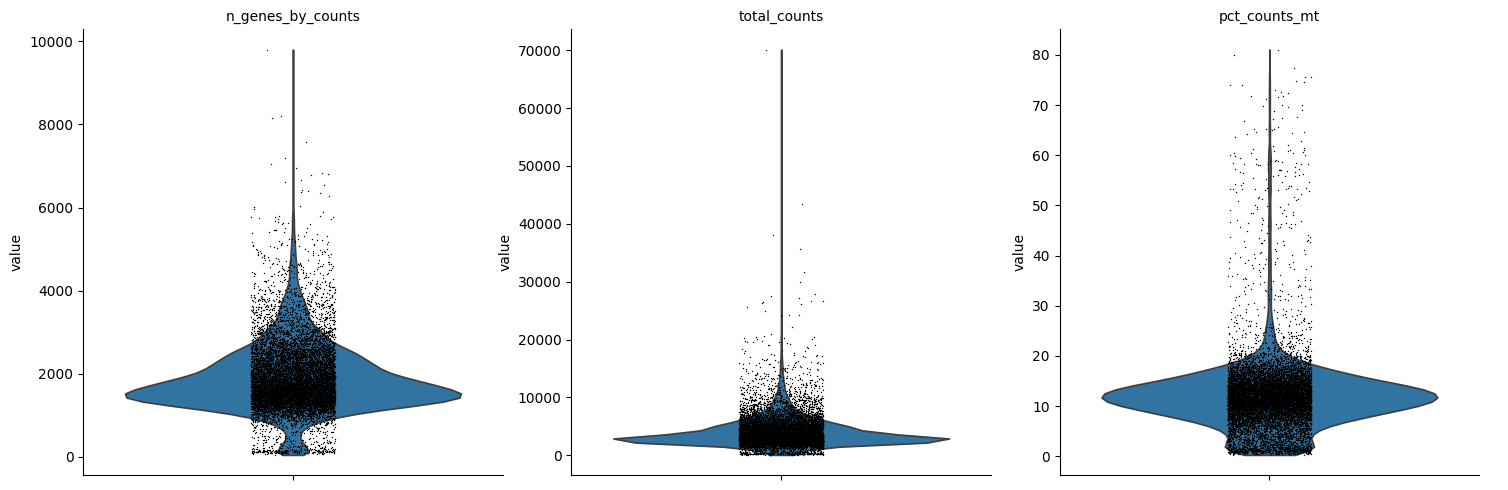

In [12]:
sc.pl.violin(rna, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], multi_panel=True)

In [39]:
rna_filt = rna[
    (rna.obs["n_genes_by_counts"] > 300) &
    (rna.obs["n_genes_by_counts"] < 5000) &
    (rna.obs["pct_counts_mt"] < 15)
].copy()

In [40]:
print(rna.shape, "->", rna_filt.shape)

(12012, 36601) -> (9438, 36601)


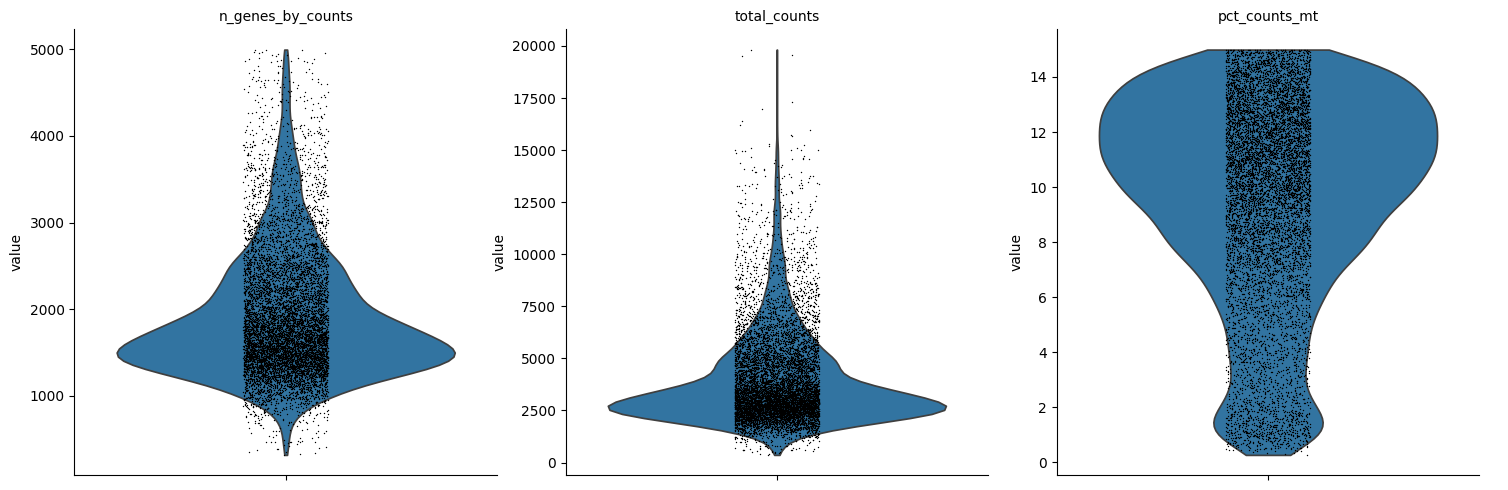

In [41]:
sc.pl.violin(rna_filt, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], multi_panel=True)

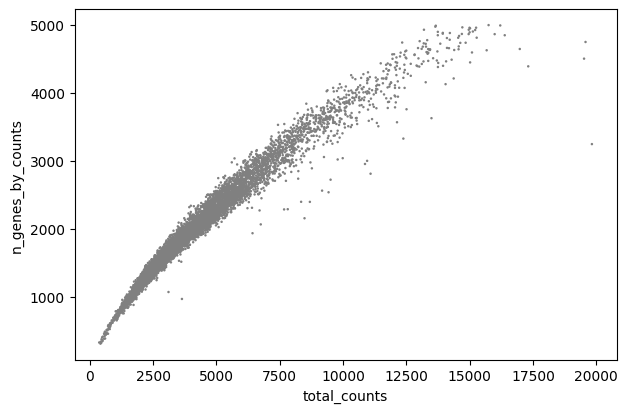

In [42]:
sc.pl.scatter(
    rna_filt,
    x="total_counts",
    y="n_genes_by_counts"
)

In [43]:
print(rna.shape)
print(rna_filt.shape)

(12012, 36601)
(9438, 36601)


In [47]:
from pathlib import Path

processed_dir = Path.home() / "projects" / "multiome-integration-scRNA-scATAC" / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

rna_filt.write(processed_dir / "rna_qc_filtered.h5ad")